# GraphLIME on RDF — live demo

**This notebook is the opening act of the presentation.** It walks the whole
argument of the project on a real knowledge graph, live, before a single
slide is shown: the problem (an RDF entity has no feature vector), the fix
(a feature space manufactured from the graph's own vocabulary), one
explanation built end to end, the checks that keep it honest, and finally
the recorded results that the slides then discuss.

Nothing here is retrained and nothing is hard-coded: every number is
recomputed from the committed checkpoints in `checkpoints/` and the raw RDF
dumps in `data/`. The only cell that takes real time is the GNNExplainer
baseline (§7, ~25 s); everything else is seconds.

```
just render      # re-execute this notebook and rebuild qualitative.html
```

**Demo route** — §1 the problem · §2 the feature space · §3 the model ·
§4 one explanation · §5 fidelity · §6 stability · §7 baseline ·
§8 the correctness gate · §9 qualitative gallery · §10 recorded results.

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
from IPython.display import Image, Markdown, display

from graphlime_rdf.config import ExperimentConfig, SyntheticConfig
from graphlime_rdf.data.loader import load_rdf_graph
from graphlime_rdf.data.synthetic import generate_ground_truth_graph
from graphlime_rdf.evaluate.agreement import agreement_at_k, graphlime_predicate_ranking
from graphlime_rdf.evaluate.fidelity import fidelity_at_k
from graphlime_rdf.evaluate.stability import jaccard_at_k
from graphlime_rdf.explain.baseline import gnnexplainer_predicate_ranking
from graphlime_rdf.explain.graphlime import Explanation, explain_node
from graphlime_rdf.features import build_features
from graphlime_rdf.pipeline import AGREEMENT_K, FIDELITY_KS, STABILITY_K, test_nodes_of
from graphlime_rdf.training import load_checkpoint, train_run

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXAMPLES_PER_DATASET = 4
TRIPLES_SHOWN = 6
HOPS_COMPARED = [1, 2, 3]


def short(term: str) -> str:
    """Compact display form of a URI/term (literals keep their value)."""
    term = term.strip("<>")
    if term.startswith('"'):  # '"value"^^<datatype>' → '"value"'
        return term.split('"^^', 1)[0] + '"'
    for sep in ["#", "/"]:
        if sep in term:
            term = term.rsplit(sep, 1)[-1]
    return term or term


def show_table(path: Path) -> None:
    """Render a generated markdown table from results/tables/."""
    display(Markdown(path.read_text()))


print(f"repository root: {REPO}")
print(f"torch {torch.__version__}")

repository root: /Users/vivri161803/Documents/Code/Unifi/XAI_Lab/graphlime-rdf
torch 2.13.0


## 1. The problem, on the actual data

AIFB is a slice of a university's semantic portal: people, research groups,
publications, projects. The task is entity classification — *which research
group does this person belong to?* The graph is loaded deterministically
from the raw `.nt.gz` dump (node, relation and label indices are assigned in
lexicographic order, so the mapping is identical in every process).

In [2]:
graph = load_rdf_graph("aifb", root=REPO / "data")
print(
    f"AIFB: {graph.num_nodes} entities, {graph.edge_index.shape[1]} triples, "
    f"{graph.num_relations} predicates, {graph.num_classes} classes\n"
    f"      {int(graph.train_mask.sum())} train / {int(graph.test_mask.sum())} test entities"
)

# The first test entity — not cherry-picked; it stays our worked example.
NODE = test_nodes_of(graph)[0]
print(f"\nworked example: node {NODE} — {short(graph.node_names[NODE])}")

AIFB: 8285 entities, 29043 triples, 45 predicates, 4 classes
      140 train / 36 test entities

worked example: node 5758 — id13instance


What does the model actually get to see about this entity? In RDF, *nothing*
but its edges — an entity carries no attributes of its own. Here are some of
the triples it participates in:

In [3]:
src, dst = graph.edge_index
outgoing = (src == NODE).nonzero().flatten()
incoming = (dst == NODE).nonzero().flatten()
me = short(graph.node_names[NODE])

for e in outgoing[:TRIPLES_SHOWN]:
    predicate = short(graph.relation_names[int(graph.edge_type[int(e)])])
    print(f"  ({me})  --{predicate}-->  {short(graph.node_names[int(dst[int(e)])])}")
for e in incoming[:TRIPLES_SHOWN]:
    predicate = short(graph.relation_names[int(graph.edge_type[int(e)])])
    print(f"  {short(graph.node_names[int(src[int(e)])])}  --{predicate}-->  ({me})")
print(
    f"\n{len(outgoing)} outgoing + {len(incoming)} incoming triples — "
    f"and not one attribute. There is no feature vector to explain."
)

  (id13instance)  --fax-->  ""
  (id13instance)  --homepage-->  "http://www.aifb.uni-karlsruhe.de/WBS/sha"
  (id13instance)  --name-->  "Siegfried Handschuh"
  (id13instance)  --phone-->  ""
  (id13instance)  --photo-->  "http://www.aifb.uni-karlsruhe.de/Personen/Bilder/U1p2l3o4a5d13"
  (id13instance)  --publication-->  id112instance
  id100instance  --isWorkedOnBy-->  (id13instance)
  id104instance  --isWorkedOnBy-->  (id13instance)
  id105instance  --isWorkedOnBy-->  (id13instance)
  id1instance  --isWorkedOnBy-->  (id13instance)
  id49instance  --isWorkedOnBy-->  (id13instance)
  id69instance  --isWorkedOnBy-->  (id13instance)

47 outgoing + 54 incoming triples — and not one attribute. There is no feature vector to explain.


This is the crux of the project. GraphLIME's whole mechanism is a selection
over *feature dimensions*: it asks which columns of a node feature matrix
the model's output depends on. In a citation network every column is a word,
readable by construction. Here there is no matrix at all — and the usual
R-GCN input, a one-hot entity id, would only ever let an explainer say
*"entity #5758 mattered"*. The explainer is not weakened; its input is
undefined.

## 2. Manufacturing the feature space

We build the missing matrix from the graph itself, in the graph's own
vocabulary. **Space A** counts predicates: `out:<p>` how many `<p>` edges
leave the node, `in:<p>` how many enter it. **Space B** is finer, one column
per predicate–object pair `out:<p>=<o>`. Both are named, so every column a
selection can return is already a term of the ontology.

In [4]:
config = ExperimentConfig.from_yaml(REPO / "configs" / "aifb.yaml")
x, vocabulary = build_features(graph, config.feature_space)
space_b = config.feature_space.model_copy(update={"kind": "predicate_object"})
xb, vocab_b = build_features(graph, space_b)

print(f"space A (predicate counts):     {tuple(x.shape)}   vocabulary hash {vocabulary.hash}")
print(f"space B (predicate=object):     {tuple(xb.shape)}   vocabulary hash {vocab_b.hash}\n")

row = x[NODE]
print(f"the row of {me} in space A — {int((row > 0).sum())} non-zero of {x.shape[1]} columns:")
for j in row.nonzero().flatten():
    print(f"    {vocabulary.names[int(j)]:<55} {float(row[int(j)]):>6.0f}")

space A (predicate counts):     (8285, 90)   vocabulary hash 1cef5620eedd82e3
space B (predicate=object):     (8285, 1424)   vocabulary hash a2639440e18240e7

the row of id13instance in space A — 11 non-zero of 90 columns:
    in:http://swrc.ontoware.org/ontology#author                 39
    in:http://swrc.ontoware.org/ontology#isWorkedOnBy           11
    in:http://swrc.ontoware.org/ontology#member                  4
    out:http://swrc.ontoware.org/ontology#fax                    1
    out:http://swrc.ontoware.org/ontology#homepage               1
    out:http://swrc.ontoware.org/ontology#name                   1
    out:http://swrc.ontoware.org/ontology#phone                  1
    out:http://swrc.ontoware.org/ontology#photo                  1
    out:http://swrc.ontoware.org/ontology#publication           39
    out:http://swrc.ontoware.org/ontology#worksAtProject         2
    out:http://www.w3.org/1999/02/22-rdf-syntax-ns#type          1


## 3. The model

An R-GCN trained on space A, loaded from the committed checkpoint of the
best seed. The bundle is self-contained — weights, resolved config, label
map and the vocabulary itself — so the notebook never retrains anything.

In [5]:
ckpt = load_checkpoint(REPO / "checkpoints" / "aifb_best.pt")
manifest = ckpt.manifest
print(
    f"checkpoint  seed={manifest.seed}  test accuracy={manifest.test_accuracy:.4f}\n"
    f"            trained at commit {manifest.git_commit} on {manifest.created_at[:10]}\n"
    f"            hidden_dim={manifest.resolved_config.model.hidden_dim}, "
    f"num_bases={manifest.resolved_config.model.num_bases}, "
    f"epochs={manifest.resolved_config.training.epochs}"
)

# The decisive invariant: the matrix we just built *is* the model's input.
assert vocabulary.hash == manifest.vocabulary_hash
print(
    f"\nvocabulary hash {vocabulary.hash} == checkpoint's {manifest.vocabulary_hash}\n"
    "→ the features the model consumes and the names the explanation returns\n"
    "  are the same objects. No translation layer, nothing to misalign."
)

edge_index, edge_type = graph.doubled_edges()
probs = ckpt.model.predict_proba(x, edge_index, edge_type)
label_names = {i: name for name, i in ckpt.label_map.items()}
predicted = int(probs[NODE].argmax())
print(
    f"\nprediction for {me}: {short(label_names[predicted])} "
    f"(p={float(probs[NODE, predicted]):.2f}), "
    f"true label {short(graph.label_names[int(graph.labels[NODE])])}"
)

checkpoint  seed=1  test accuracy=0.9444
            trained at commit b1d8ed5 on 2026-08-31
            hidden_dim=32, num_bases=30, epochs=200

vocabulary hash 1cef5620eedd82e3 == checkpoint's 1cef5620eedd82e3
→ the features the model consumes and the names the explanation returns
  are the same objects. No translation layer, nothing to misalign.

prediction for id13instance: id3instance (p=1.00), true label id3instance


## 4. One explanation, end to end

GraphLIME samples the node's k-hop neighbourhood, takes those rows of the
feature matrix and the model's output probabilities on the same rows, and
runs a non-negative HSIC Lasso: which feature columns carry the local
dependence between input and prediction? The weights β are non-negative and
sparse, and each one is attached to a predicate name.

In [6]:
started = time.perf_counter()
explanation = explain_node(
    ckpt.model, NODE, x, edge_index, edge_type, vocabulary, config.graphlime
)
elapsed = time.perf_counter() - started
assert isinstance(explanation, Explanation)

print(
    f"neighbourhood: {explanation.neighborhood_size} nodes at "
    f"hops={config.graphlime.hops}, ρ={config.graphlime.rho}   "
    f"[{elapsed:.2f} s]\n"
    f"sparsity: {explanation.sparsity:.3f} of {len(vocabulary)} columns are exactly zero\n"
)
selected = explanation.top_features(len(explanation.beta))
total = sum(beta for _, beta in selected)
print(f"{len(selected)} of {len(vocabulary)} columns received a non-zero weight:\n")
for name, beta in selected[:5]:
    direction, predicate = name.split(":", 1)
    word = "outgoing" if direction == "out" else "incoming"
    print(f"    β={beta:.4f}  ({100 * beta / total:>4.1f}% of the weight)  "
          f"{word:>8}  {short(predicate)}")

print(
    f"\n→ {me} is predicted to belong to {short(label_names[predicted])}\n"
    f"  because of its {short(explanation.top_features(1)[0][0])} edges."
)

neighbourhood: 1768 nodes at hops=2, ρ=0.1   [0.16 s]
sparsity: 0.967 of 90 columns are exactly zero

4 of 90 columns received a non-zero weight:

    β=0.0215  (60.4% of the weight)  incoming  projectInfo
    β=0.0124  (35.1% of the weight)  incoming  title
    β=0.0016  ( 4.5% of the weight)  outgoing  fax
    β=0.0000  ( 0.0% of the weight)  outgoing  phone

→ id13instance is predicted to belong to id3instance
  because of its projectInfo edges.


## 5. Is the explanation faithful? — fidelity±

A readable explanation is not necessarily a true one. We zero the top-k
columns graph-wide and watch the predicted probability: **fidelity+** =
p(full) − p(top-k removed), high is good — the model really needed them.
**fidelity−** = p(full) − p(only top-k kept), low is good — they suffice on
their own. Against each we run a random-k control on the same node.

In [7]:
ranked_columns = [int(j) for j in np.argsort(-explanation.beta, kind="stable")]
print(f"{'k':>3}  {'fidelity+':>10} {'random+':>9}   {'fidelity−':>10} {'random−':>9}")
for k in FIDELITY_KS:
    fid_plus, fid_minus, rand_plus, rand_minus = fidelity_at_k(
        ckpt.model, x, edge_index, edge_type, NODE, ranked_columns, k
    )
    print(
        f"{k:>3}  {fid_plus:>10.4f} {rand_plus:>9.4f}   "
        f"{fid_minus:>10.4f} {rand_minus:>9.4f}"
    )
print("\n(one node only — the aggregate over all test nodes is in §10)")

  k   fidelity+   random+    fidelity−   random−


  1      0.0000    0.0000       0.4398    0.6884


  2      0.0000    0.0000       0.5106    0.7672


  5      0.0000    0.0000       0.4761    0.7480


 10      0.0000    0.0000       0.0000    0.0000

(one node only — the aggregate over all test nodes is in §10)


Read this honestly. The prediction for this entity is saturated at p = 1.00,
so removing a handful of columns does not move it at all and fidelity+ is
flat — a single confident node simply cannot separate a good explanation
from a bad one. What the fidelity− column does say is that the selected
features alone recover the prediction better than a random set of the same
size. The verdict belongs to the average over all test nodes and all values
of k, in §10; that is why the reported metric is never read off one example.

## 6. Is it stable? — the same node at 1, 2 and 3 hops

The neighbourhood radius is a choice, not a fact about the data. If the
explanation survives changing it, the selection is about the entity; if it
does not, we should say so. Jaccard@5 over the top-5 feature sets:

In [8]:
by_hops = {}
for hops in HOPS_COMPARED:
    gl = config.graphlime.model_copy(update={"hops": hops})
    out = explain_node(ckpt.model, NODE, x, edge_index, edge_type, vocabulary, gl)
    assert isinstance(out, Explanation)
    by_hops[hops] = out
    top = ", ".join(short(name.split(":", 1)[1]) for name, _ in out.top_features(3))
    print(f"hops={hops}  ({out.neighborhood_size:>4} nodes)  top-3: {top}")

print()
for a, b in zip(HOPS_COMPARED, HOPS_COMPARED[1:], strict=False):
    print(
        f"Jaccard@{STABILITY_K}  hops={a} vs hops={b}: "
        f"{jaccard_at_k(by_hops[a], by_hops[b], STABILITY_K):.4f}"
    )

hops=1  (  60 nodes)  top-3: howpublished, projectInfo, photo


hops=2  (1768 nodes)  top-3: projectInfo, title, fax


hops=3  (5669 nodes)  top-3: name, type, title

Jaccard@5  hops=1 vs hops=2: 0.1250
Jaccard@5  hops=2 vs hops=3: 0.2857


## 7. Against a baseline — GNNExplainer on the same features

PyG's edge-mask machinery is structurally incompatible with `RGCNConv`, so
the baseline learns its **attribute mask** over the very same named feature
matrix. Both explainers therefore rank the same predicates and the
comparison is honest. This is the slow cell of the demo (~25 s: the baseline
optimises a mask for 100 epochs, while GraphLIME above closed a convex
problem in a fraction of a second).

In [9]:
started = time.perf_counter()
baseline_ranking = gnnexplainer_predicate_ranking(
    ckpt.model, x, edge_index, edge_type, vocabulary, NODE
)
print(f"GNNExplainer: {time.perf_counter() - started:.1f} s\n")

graphlime_ranking = graphlime_predicate_ranking(explanation)
print(f"{'GraphLIME':<20} {'β':>9}   {'GNNExplainer':<20} {'mask':>9}")
for rank in range(AGREEMENT_K):
    ga, wa = graphlime_ranking[rank] if rank < len(graphlime_ranking) else ("—", 0.0)
    gb, wb = baseline_ranking[rank] if rank < len(baseline_ranking) else ("—", 0.0)
    print(f"{short(ga):<20} {wa:>9.4f}   {short(gb):<20} {wb:>9.4f}")
print(
    f"\nagreement@{AGREEMENT_K} (Jaccard of the top-{AGREEMENT_K} predicate sets): "
    f"{agreement_at_k(graphlime_ranking, baseline_ranking, AGREEMENT_K):.4f}"
)

GNNExplainer: 21.9 s

GraphLIME                    β   GNNExplainer              mask
projectInfo             0.0215   abstract                0.0000
title                   0.0124   address                 0.0000
fax                     0.0016   author                  0.0000
phone                   0.0000   booktitle               0.0000
—                       0.0000   carriedOutBy            0.0000

agreement@5 (Jaccard of the top-5 predicate sets): 0.0000


Look at the baseline's weights, not just its names: its attribute mask
leaves most predicates tied at zero on this node, so its "top-5" is
whatever the alphabet puts first and the agreement collapses to 0. The two
explainers are not measuring the same thing — GraphLIME solves a convex
selection over the neighbourhood's feature rows, GNNExplainer optimises a
per-run mask — and the aggregate agreement (§10) is low on AIFB and moderate
on MUTAG. A baseline that disagrees is reported as such, not tuned until it
agrees.

## 8. The correctness gate — a graph whose answer we already know

Everything above is unverifiable on real data: nobody knows the true reason
for an AIFB label. So the project's hard gate runs on a synthetic RDF graph
in which one predicate *is* the class by construction. If GraphLIME cannot
recover a planted answer, no number on AIFB or MUTAG may be reported.

The gate itself lives in `tests/test_synthetic_gate.py` (`just synthetic`);
what follows replays it live, over all test entities of the graph.

In [10]:
syn_cfg = SyntheticConfig()
syn_graph = generate_ground_truth_graph(syn_cfg)
syn_config = ExperimentConfig.from_yaml(REPO / "configs" / "synthetic.yaml")
target_feature = f"out:syn:p{syn_cfg.target_predicate}"

started = time.perf_counter()
syn_result = train_run(syn_graph, syn_config, seed=0)
print(
    f"planted rule: class 1 ⟺ the entity has a {target_feature} edge "
    f"({syn_cfg.num_entities} entities, {syn_cfg.num_predicates} predicates)\n"
    f"R-GCN test accuracy: {syn_result.manifest.final_test_accuracy:.4f} "
    f"[trained in {time.perf_counter() - started:.1f} s]\n"
)

ranks = []
for node in test_nodes_of(syn_graph):
    out = explain_node(
        syn_result.model, node, syn_result.x, syn_result.edge_index,
        syn_result.edge_type, syn_result.vocabulary, syn_config.graphlime,
    )
    if isinstance(out, Explanation):
        names = [name for name, _ in out.top_features(len(out.beta))]
        ranks.append(names.index(target_feature) + 1 if target_feature in names else 10**6)

top1 = sum(r == 1 for r in ranks) / len(ranks)
print(
    f"over {len(ranks)} test entities, {target_feature} is ranked FIRST "
    f"{top1:.1%} of the time\n"
    f"(the gate's contractual threshold is 95%, and it is never lowered)"
)

planted rule: class 1 ⟺ the entity has a out:syn:p7 edge (400 entities, 10 predicates)
R-GCN test accuracy: 1.0000 [trained in 0.8 s]



over 80 test entities, out:syn:p7 is ranked FIRST 100.0% of the time
(the gate's contractual threshold is 95%, and it is never lowered)


## 9. Qualitative gallery — explanations as sentences

The same machinery over several test entities of both datasets, read out as
*"predicted group X because of predicate P toward Y"*. Here we switch the
interpretable matrix to **space B** so the explanation can name the specific
term at the end of the edge; the model input stays space A (its own
vocabulary, verified by hash above). That is exactly the feature-space
flexibility measured in the agreement experiment.

In [11]:
def explain_examples(dataset: str) -> None:
    """Sentence-form explanations in feature space B: predicate *toward* term."""
    ckpt = load_checkpoint(REPO / "checkpoints" / f"{dataset}_best.pt")
    cfg = ckpt.manifest.resolved_config
    graph = load_rdf_graph(dataset, root=REPO / "data")
    x, vocabulary = build_features(graph, cfg.feature_space)
    assert vocabulary.hash == ckpt.manifest.vocabulary_hash
    space_b = cfg.feature_space.model_copy(update={"kind": "predicate_object"})
    xb, vocab_b = build_features(graph, space_b)
    # Qualitative display: gentler regularisation than the quantitative runs
    # (rho=0.1 in results/) so the sparser (p,o) features surface; stated here
    # openly — the recorded metrics never use this value.
    gl_cfg = cfg.graphlime.model_copy(update={"rho": 0.01})
    edge_index, edge_type = graph.doubled_edges()
    probs = ckpt.model.predict_proba(x, edge_index, edge_type)
    label_names = {i: name for name, i in ckpt.label_map.items()}

    shown = 0
    for node in test_nodes_of(graph):
        out = explain_node(
            ckpt.model, node, x, edge_index, edge_type, vocab_b, gl_cfg,
            interpretable_x=xb,
        )
        if not isinstance(out, Explanation):
            print(f"— node {node}: refused ({out.reason})\n")
            continue
        predicted = int(probs[node].argmax())
        correct = "correctly" if predicted == int(graph.labels[node]) else "INCORRECTLY"
        top = out.top_features(3)
        reasons = "; ".join(
            f"{short(name.split(':', 1)[1].split('=')[0])} "
            f"({'outgoing' if name.startswith('out:') else 'incoming'}, β={beta:.2f})"
            + (f" toward {short(name.split('=', 1)[1])}" if "=" in name else "")
            for name, beta in top
        ) or f"no feature selected at ρ={gl_cfg.rho} (locally uniform prediction)"
        print(
            f"{graph.dataset.upper()} node {node} — {short(graph.node_names[node])}\n"
            f"  {correct} predicted {short(label_names[predicted])} "
            f"(p={float(probs[node, predicted]):.2f}, "
            f"neighborhood={out.neighborhood_size})\n"
            f"  because of: {reasons}\n"
        )
        shown += 1
        if shown >= EXAMPLES_PER_DATASET:
            break

### AIFB — which research group does a person belong to?

In [12]:
explain_examples("aifb")

AIFB node 5758 — id13instance
  correctly predicted id3instance (p=1.00, neighborhood=1768)
  because of: publishes (incoming, β=0.06) toward id3instance; homepage (outgoing, β=0.05) toward "None"; type (outgoing, β=0.04) toward Person



AIFB node 5766 — id1851instance
  correctly predicted id1instance (p=1.00, neighborhood=1094)
  because of: member (incoming, β=0.05) toward id1instance; homepage (outgoing, β=0.04) toward "None"; author (incoming, β=0.04) toward id356instance



AIFB node 5769 — id1855instance
  correctly predicted id1instance (p=1.00, neighborhood=1094)
  because of: member (incoming, β=0.10) toward id2instance; member (incoming, β=0.06) toward id1instance; member (incoming, β=0.05) toward id4instance



AIFB node 5772 — id1860instance
  correctly predicted id1instance (p=1.00, neighborhood=1094)
  because of: fax (outgoing, β=0.05) toward ""; member (incoming, β=0.05) toward id2instance; isWorkedOnBy (incoming, β=0.04) toward id9instance



### MUTAG — is a compound mutagenic?

In [13]:
explain_examples("mutag")

MUTAG node 11481 — d103
  correctly predicted 0.0 (p=0.60, neighborhood=400)
  because of: cytogen_ca (outgoing, β=0.04) toward "false"; salmonella (outgoing, β=0.03) toward "false"; type (outgoing, β=0.02) toward DatatypeProperty

MUTAG node 11533 — d107
  correctly predicted 1.0 (p=1.00, neighborhood=721)
  because of: type (outgoing, β=0.20) toward Compound; type (outgoing, β=0.11) toward Chlorine-93; cytogen_ca (outgoing, β=0.10) toward "false"



MUTAG node 11676 — d108
  correctly predicted 0.0 (p=0.61, neighborhood=461)
  because of: cytogen_ca (outgoing, β=0.10) toward "false"; type (outgoing, β=0.05) toward Compound; salmonella (outgoing, β=0.04) toward "false"

MUTAG node 11792 — d112
  correctly predicted 1.0 (p=1.00, neighborhood=486)
  because of: cytogen_ca (outgoing, β=0.08) toward "false"; type (outgoing, β=0.08) toward Compound; mouse_lymph (outgoing, β=0.05) toward "false"



### Reading the output

Each block is one test entity: the model's prediction with its confidence,
the neighbourhood size GraphLIME sampled, and the three predicates with the
largest non-negative HSIC-Lasso weights β. A comparatively large β
concentrated on one predicate means the local dependence between features
and prediction runs mostly through that predicate; absolute magnitudes are
small because β is shared across a sparse solution over hundreds of
(p,o)-pair features. Refused nodes (neighbourhood below
`min_neighborhood`) are printed as refusals — they are counted in
`results/tables/refusals.md`, not hidden.

## 10. The recorded results — and the handover to the slides

Everything above was one node, or one graph, computed live. The tables below
are the canonical numbers: generated by `just tables` from the validated
JSONL records in `results/`, over all test entities and all five seeds.
Every figure quoted in the report and in the slide deck comes from here.

In [14]:
TABLES = REPO / "results" / "tables"
for title, name in [
    ("### Classification accuracy — 5 seeds", "main_results.md"),
    ("### Fidelity± against the random-k control", "fidelity.md"),
    ("### Stability across seeds and hops (Jaccard@5)", "stability.md"),
    ("### Feature-space sensitivity and baseline agreement", "agreement.md"),
    ("### Refusals", "refusals.md"),
]:
    display(Markdown(title))
    show_table(TABLES / name)

### Classification accuracy — 5 seeds

| dataset | test accuracy (mean ± std, 5 seeds) | per-seed | best seed | best accuracy | checkpoint sha256 |
|---|---|---|---|---|---|
| AIFB | 0.8833 ± 0.0534 | 0.9167, 0.9444, 0.8056, 0.8889, 0.8611 | 1 | 0.9444 | `8f69360a52b0` |
| MUTAG | 0.7559 ± 0.0305 | 0.7794, 0.7206, 0.7353, 0.7500, 0.7941 | 4 | 0.7941 | `20de0d5614ec` |


### Fidelity± against the random-k control

| dataset | k | fidelity+ | random+ | fidelity− | random− | nodes |
|---|---|---|---|---|---|---|
| AIFB | 1 | 0.0176 | 0.0129 | 0.7145 | 0.6767 | 36 |
| AIFB | 2 | 0.0162 | 0.0066 | 0.7386 | 0.7556 | 36 |
| AIFB | 5 | 0.1079 | 0.0520 | 0.7160 | 0.6085 | 36 |
| AIFB | 10 | 0.1829 | 0.0735 | 0.6338 | 0.6184 | 36 |
| MUTAG | 1 | 0.0789 | -0.0013 | 0.5397 | 0.3151 | 68 |
| MUTAG | 2 | 0.1224 | 0.0205 | 0.3068 | 0.2744 | 68 |
| MUTAG | 5 | 0.1627 | 0.0475 | 0.1987 | 0.3352 | 68 |
| MUTAG | 10 | 0.0999 | 0.1592 | 0.2299 | 0.3462 | 68 |


### Stability across seeds and hops (Jaccard@5)

| dataset | comparison | pair | mean Jaccard@5 | pairs |
|---|---|---|---|---|
| AIFB | hops | hops=1 vs hops=2 | 0.0413 | 21 |
| AIFB | hops | hops=2 vs hops=3 | 0.0585 | 36 |
| AIFB | seeds | seed=0 vs seed=1 | 0.2443 | 36 |
| AIFB | seeds | seed=1 vs seed=2 | 0.5162 | 36 |
| AIFB | seeds | seed=2 vs seed=3 | 0.4547 | 36 |
| AIFB | seeds | seed=3 vs seed=4 | 0.4239 | 36 |
| MUTAG | hops | hops=1 vs hops=2 | 0.0103 | 68 |
| MUTAG | hops | hops=2 vs hops=3 | 0.0696 | 68 |
| MUTAG | seeds | seed=0 vs seed=1 | 0.3593 | 68 |
| MUTAG | seeds | seed=1 vs seed=2 | 0.1709 | 68 |
| MUTAG | seeds | seed=2 vs seed=3 | 0.3179 | 68 |
| MUTAG | seeds | seed=3 vs seed=4 | 0.7475 | 68 |


### Feature-space sensitivity and baseline agreement

| dataset | comparison | mean Jaccard@5 (predicates) | nodes |
|---|---|---|---|
| AIFB | GraphLIME: space A vs space B | 0.2843 | 36 |
| AIFB | GraphLIME vs GNNExplainer | 0.1456 | 36 |
| MUTAG | GraphLIME: space A vs space B | 0.0029 | 68 |
| MUTAG | GraphLIME vs GNNExplainer | 0.3153 | 68 |


### Refusals

| dataset | explained | refused | refusal rate | reasons |
|---|---|---|---|---|
| AIFB | 36 | 0 | 0.0000 | — |
| MUTAG | 68 | 0 | 0.0000 | — |


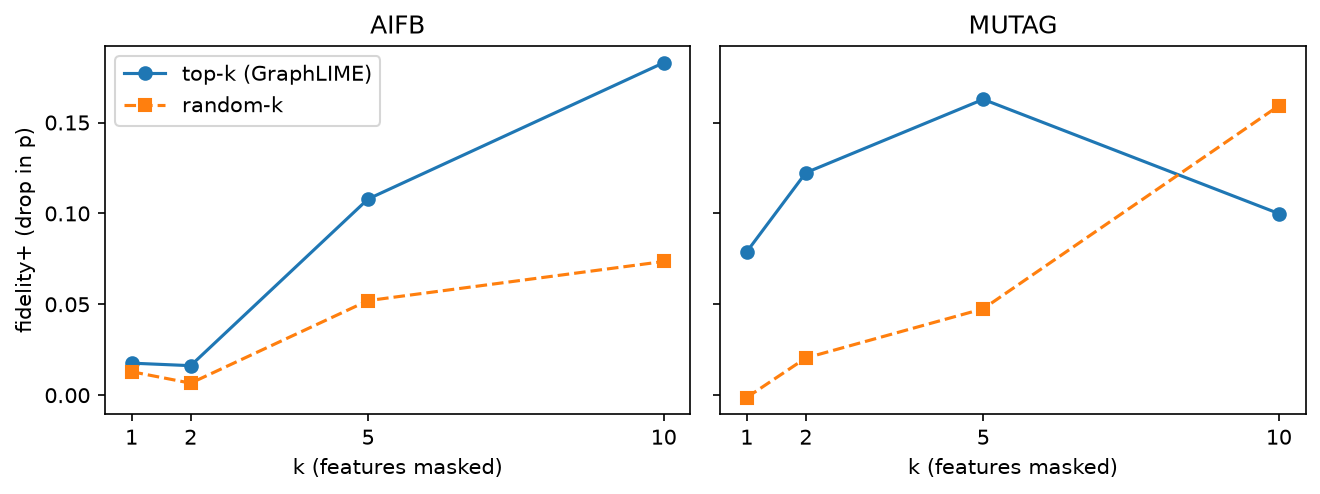

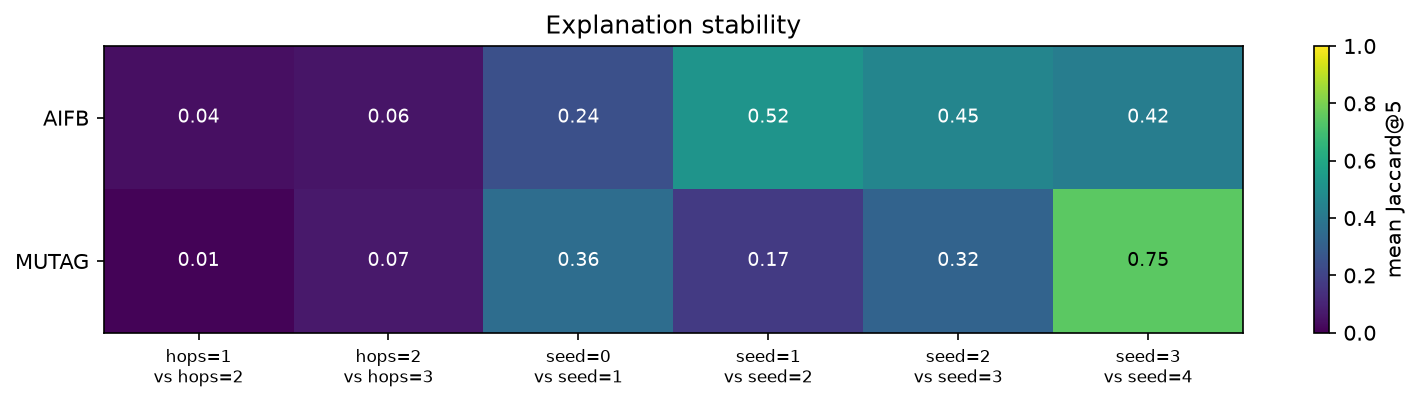

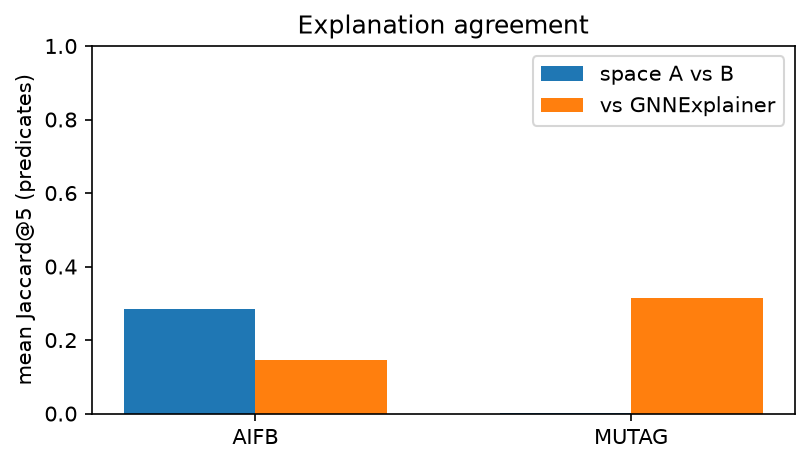

In [15]:
FIGURES = REPO / "results" / "figures"
for name in ["fidelity_curve.png", "stability_heatmap.png", "agreement_comparison.png"]:
    display(Image(filename=str(FIGURES / name)))

---

**Where this leaves the presentation.** The demo has shown that the pipeline
runs, that the explanations are in the vocabulary of the graph, and that the
method recovers a planted ground truth. What it cannot show in one node is
whether the selections beat their controls at scale, how far the two feature
spaces diverge, or where the method breaks down — that is what the tables
above summarise and what the slides now discuss, from
`report/presentazione.pdf` (full argument in `report/relazione.pdf`).